In [3]:
import os
import sys

project_root = os.path.abspath(os.path.join('..'))
if project_root not in sys.path:
    sys.path.append(project_root)

In [9]:
from src.analysis.indicators import get_indicator_data
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
INDICATORS = [
    "IT.NET.USER.ZS",
    "IT.CEL.SETS.P2",
    "IT.NET.BBND.P2",
    "EG.ELC.ACCS.ZS",
    "NY.GDP.PCAP.CD"
]

In [8]:
all_data = []

for indicator in INDICATORS:

    indicator_data = get_indicator_data(indicator)
    all_data.append(indicator_data)

df = pd.concat(all_data, ignore_index=True)

df.tail()

,country_code,country_name,indicator_code,indicator_name,dimension,year,value,unit
358,ZAF,South Africa,NY.GDP.PCAP.CD,GDP per capita,Context,2021,6828.756246,Current US dollars
359,ZAF,South Africa,NY.GDP.PCAP.CD,GDP per capita,Context,2022,6534.248678,Current US dollars
360,ZAF,South Africa,NY.GDP.PCAP.CD,GDP per capita,Context,2023,6034.27209,Current US dollars
361,ZAF,South Africa,NY.GDP.PCAP.CD,GDP per capita,Context,2024,6267.186814,Current US dollars
362,ZAF,South Africa,NY.GDP.PCAP.CD,GDP per capita,Context,2025,6597.714509,Current US dollars


In [10]:
df.shape

(363, 8)

In [11]:
df["indicator_code"].value_counts()

indicator_code
NY.GDP.PCAP.CD    96
IT.NET.USER.ZS    90
IT.CEL.SETS.P2    90
IT.NET.BBND.P2    87
Name: count, dtype: int64

In [12]:
df[["indicator_code", "indicator_name"]].drop_duplicates()

,indicator_code,indicator_name
0,IT.NET.USER.ZS,Individuals using the Internet
90,IT.CEL.SETS.P2,Mobile cellular subscriptions
180,IT.NET.BBND.P2,Fixed broadband subscriptions
267,NY.GDP.PCAP.CD,GDP per capita


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 363 entries, 0 to 362
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   country_code    363 non-null    object
 1   country_name    363 non-null    object
 2   indicator_code  363 non-null    object
 3   indicator_name  363 non-null    object
 4   dimension       363 non-null    object
 5   year            363 non-null    object
 6   value           363 non-null    object
 7   unit            363 non-null    object
dtypes: object(8)
memory usage: 22.8+ KB


In [15]:
df.describe()

,country_code,country_name,indicator_code,indicator_name,dimension,year,value,unit
count,363,363,363,363,363,363,363.0,363
unique,6,6,4,4,2,16,362.0,3
top,GHA,Ghana,NY.GDP.PCAP.CD,GDP per capita,Digital Access,2010,9.0,Per 100 people
freq,61,61,96,96,267,24,2.0,177


In [16]:
df.isnull().sum()

country_code      0
country_name      0
indicator_code    0
indicator_name    0
dimension         0
year              0
value             0
unit              0
dtype: int64

In [17]:
df["country_name"].unique()

array(['Cameroon', 'Ghana', 'Kenya', 'Nigeria', 'Rwanda', 'South Africa'],
      dtype=object)

In [18]:
print("Earliest year:", df["year"].min())
print("Latest year:", df["year"].max())

Earliest year: 2010
Latest year: 2025


In [19]:
df.groupby("indicator_name").size().sort_values(ascending=False)

indicator_name
GDP per capita                    96
Individuals using the Internet    90
Mobile cellular subscriptions     90
Fixed broadband subscriptions     87
dtype: int64

In [ ]:
# Coverage by country and indicator

coverage = pd.pivot_table(df, index="country_name", columns="indicator_name", values="value", aggfunc="count")

coverage

indicator_name,Fixed broadband subscriptions,GDP per capita,Individuals using the Internet,Mobile cellular subscriptions
country_name,,,,
Cameroon,13,16,15,15
Ghana,15,16,15,15
Kenya,15,16,15,15
Nigeria,14,16,15,15
Rwanda,15,16,15,15
South Africa,15,16,15,15


In [21]:
coverage.fillna(0).astype(int)

indicator_name,Fixed broadband subscriptions,GDP per capita,Individuals using the Internet,Mobile cellular subscriptions
country_name,,,,
Cameroon,13,16,15,15
Ghana,15,16,15,15
Kenya,15,16,15,15
Nigeria,14,16,15,15
Rwanda,15,16,15,15
South Africa,15,16,15,15


In [ ]:
# Analyze all indicators' trends automatically

def plot_all_indicator_trends(df):

    indicators = df["indicator_name"].unique()

    for indicator in indicators:

        indicator_df = df[df["indicator_name"] == indicator]

        plt.figure(figsize=(12, 6))

        for country in indicator_df["country_name"].unique():

            country_data = indicator_df[indicator_df["country_name"] == country]

            plt.plot(
                country_data["year"],
                country_data["value"],
                marker="o",
                label=country
            )

        unit = indicator_df["unit"].iloc[0]

        plt.title(f"{indicator} Over Time")
        plt.xlabel("Year")
        plt.ylabel(unit)
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

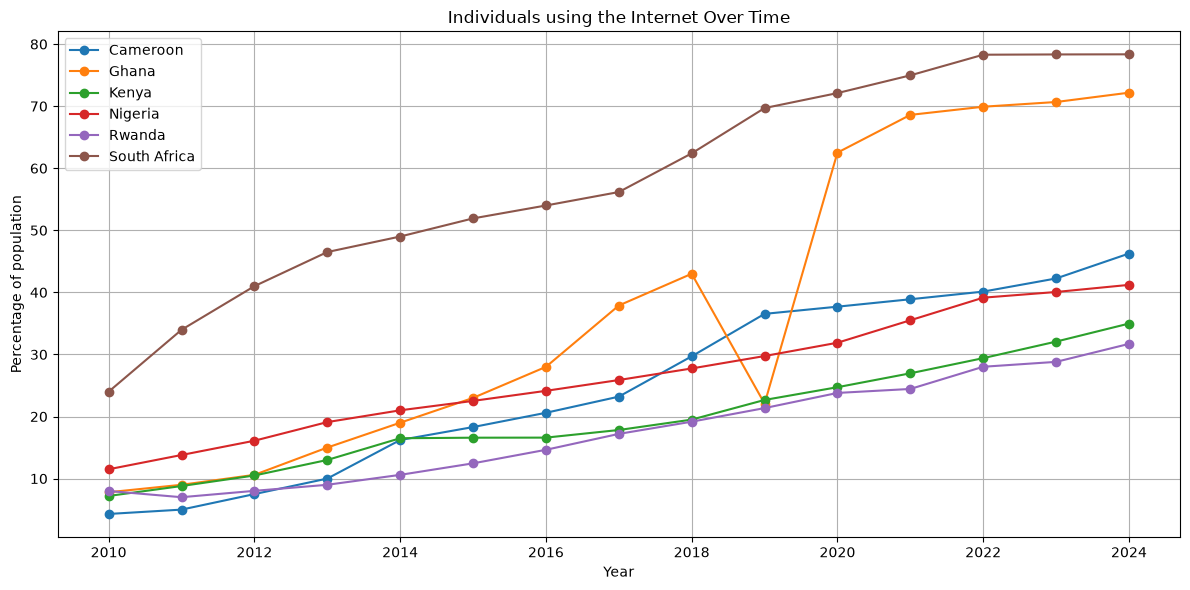

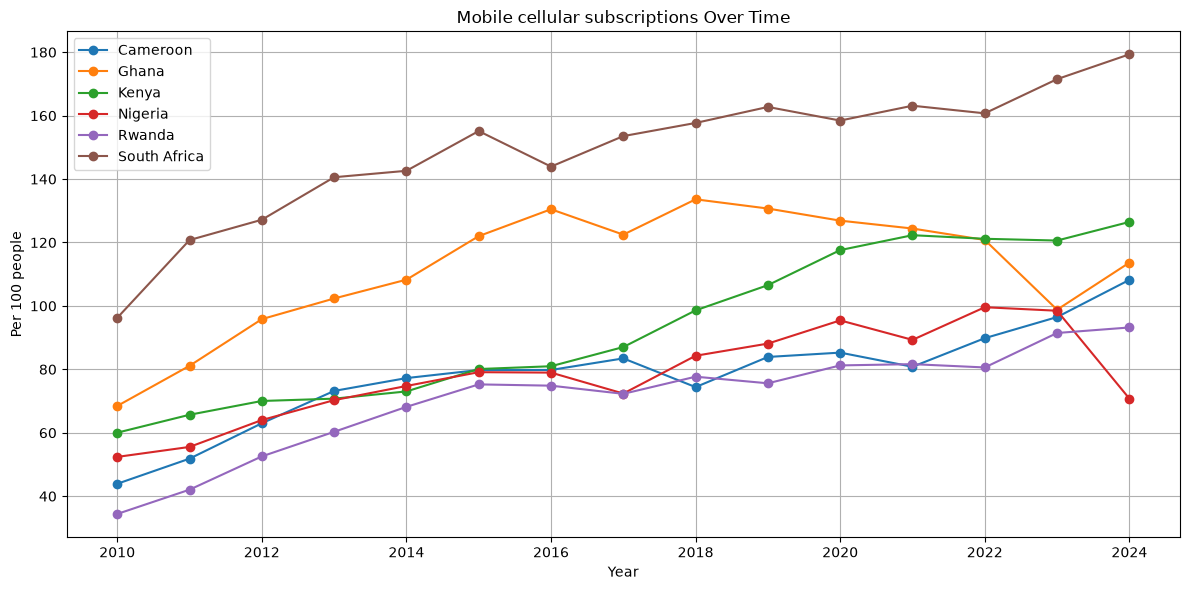

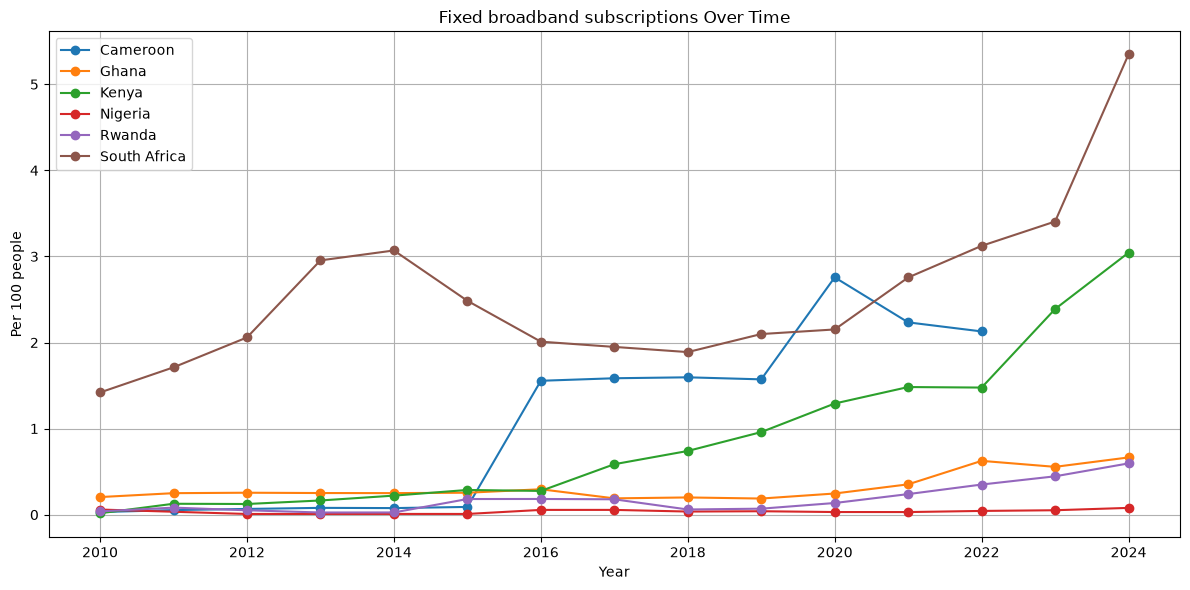

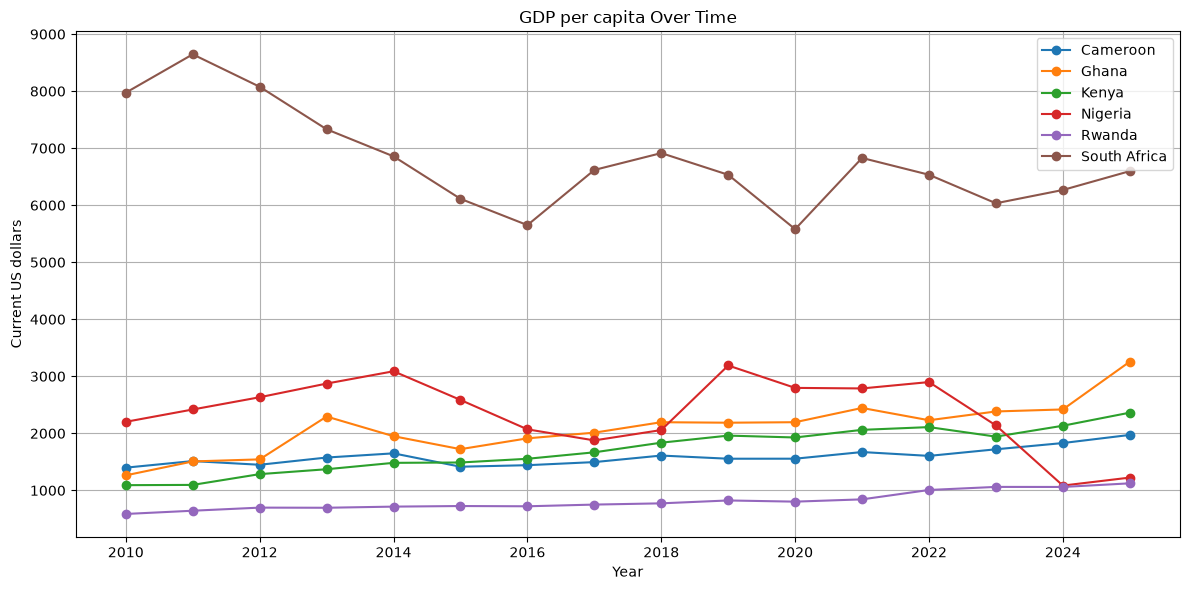

In [24]:
plot_all_indicator_trends(df)

In [ ]:
# Latest-value comparison for every indicator

latest = (df.sort_values("year").groupby(["country_name", "indicator_code"]).tail(1))

In [30]:
latest[["country_name", "indicator_name", "year", "value", "unit"]]

,country_name,indicator_name,year,value,unit
192,Cameroon,Fixed broadband subscriptions,2022,2.128625,Per 100 people
44,Kenya,Individuals using the Internet,2024,34.976225,Percentage of population
59,Nigeria,Individuals using the Internet,2024,41.211399,Percentage of population
74,Rwanda,Individuals using the Internet,2024,31.7033,Percentage of population
89,South Africa,Individuals using the Internet,2024,78.357597,Percentage of population
104,Cameroon,Mobile cellular subscriptions,2024,108.21313,Per 100 people
119,Ghana,Mobile cellular subscriptions,2024,113.647967,Per 100 people
134,Kenya,Mobile cellular subscriptions,2024,126.477706,Per 100 people
29,Ghana,Individuals using the Internet,2024,72.175697,Percentage of population
149,Nigeria,Mobile cellular subscriptions,2024,70.761906,Per 100 people


In [31]:
def plot_latest_values(df):

    indicators = df["indicator_name"].unique()

    for indicator in indicators:

        indicator_df = df[df["indicator_name"] == indicator]

        latest_data = (indicator_df.sort_values("year").groupby("country_name").tail(1).sort_values("value"))

        plt.figure(figsize=(10, 6))

        plt.bar(
            latest_data["country_name"],
            latest_data["value"]
        )
        plt.title(f"Latest {indicator} by country")
        plt.xlabel("Country")
        plt.ylabel(latest_data["unit"].iloc[0])
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

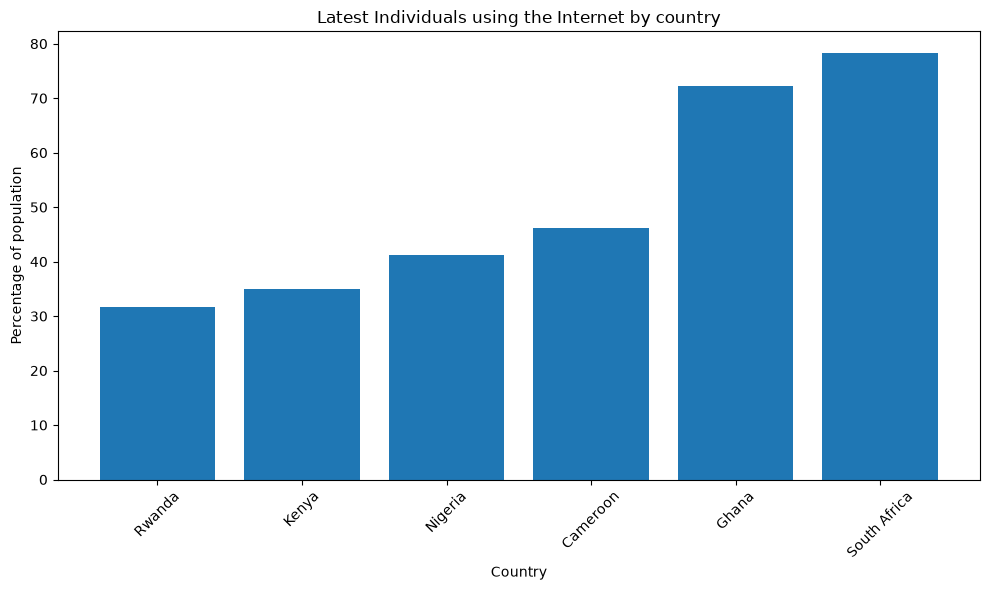

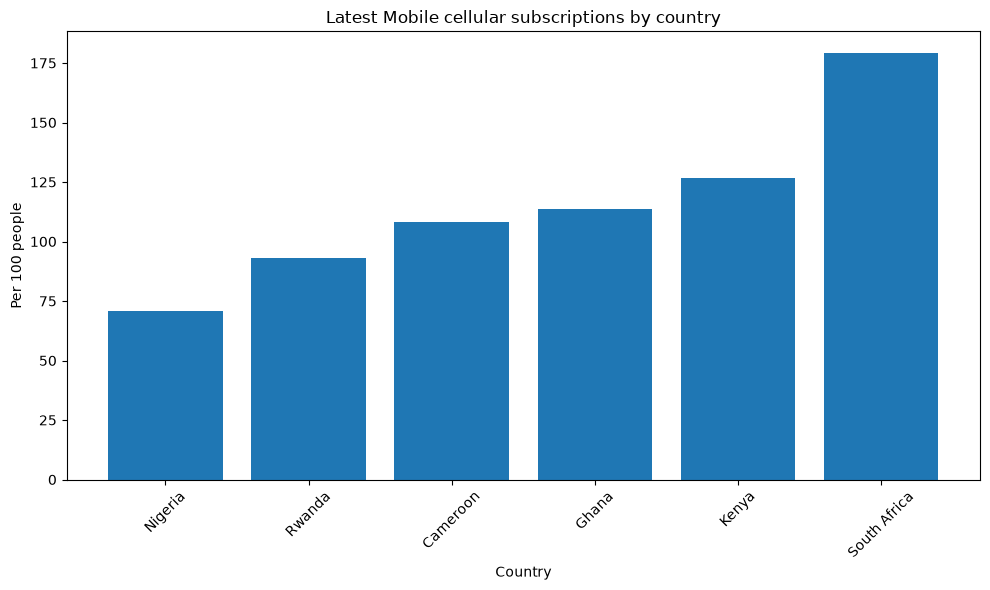

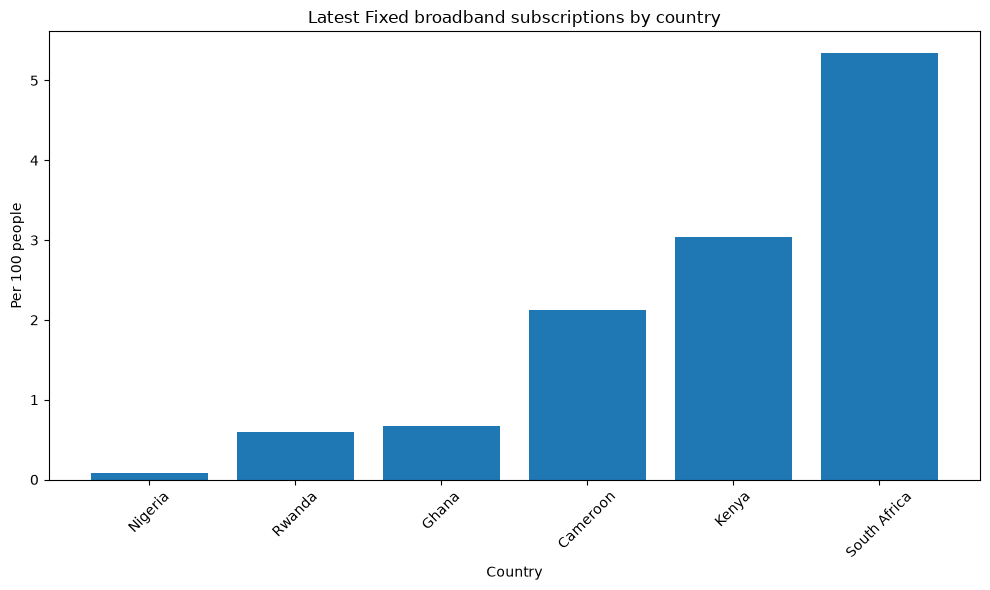

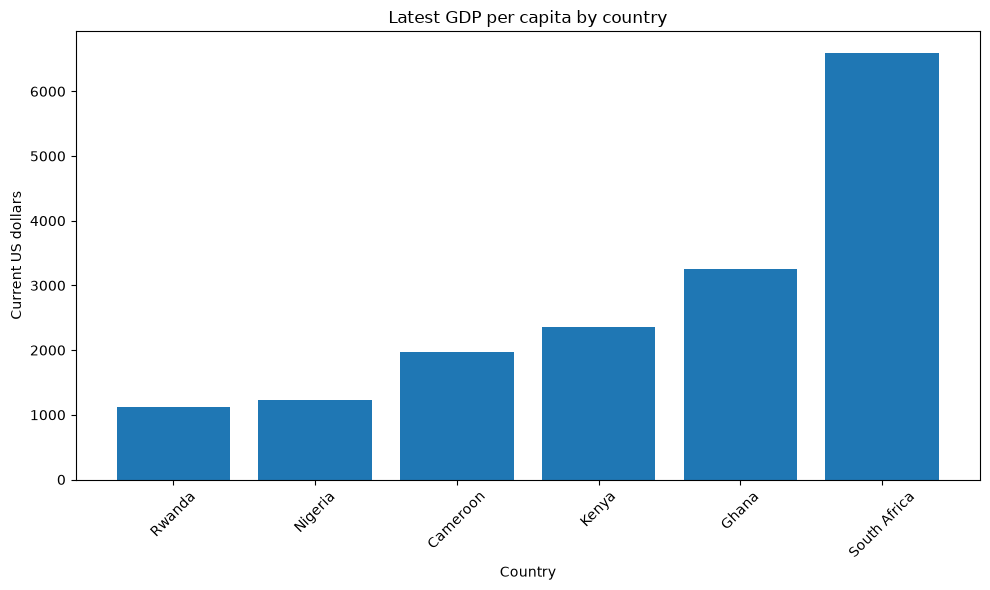

In [33]:
plot_latest_values(df)

In [ ]:
# Analyze improvement across the period

def calculate_period_change(df):

    results = []

    grouped = df.groupby(
        [
            "country_name",
            "indicator_code",
            "indicator_name",
            "unit"
        ]
    )

    for (country, indicator_code, indicator_name, unit), group in grouped:

        group = group.sort_values("year")

        first = group.iloc[0]
        last = group.iloc[-1]

        absolute_change = (last["value"] - first["value"])

        if first["value"] != 0:
            percentage_change = (absolute_change / first["value"]) * 100
        else:
            percentage_change = None

        results.append({
            "country_name": country,
            "indicator_code": indicator_code,
            "indicator_name": indicator_name,
            "unit": unit,
            "first_year": first["year"],
            "first_value": first["value"],
            "last_year": last["year"],
            "last_value": last["value"],
            "absolute_change": absolute_change,
            "percentage_change": percentage_change
        })

    return pd.DataFrame(results)

In [35]:
period_change = calculate_period_change(df)
period_change.head()

,country_name,indicator_code,indicator_name,unit,first_year,first_value,last_year,last_value,absolute_change,percentage_change
0,Cameroon,IT.CEL.SETS.P2,Mobile cellular subscriptions,Per 100 people,2010,43.912055,2024,108.213130,64.301075,146.431486
1,Cameroon,IT.NET.BBND.P2,Fixed broadband subscriptions,Per 100 people,2010,0.030272,2022,2.128625,2.098352,6931.563971
2,Cameroon,IT.NET.USER.ZS,Individuals using the Internet,Percentage of population,2010,4.300000,2024,46.258801,41.958800,975.786011
3,Cameroon,NY.GDP.PCAP.CD,GDP per capita,Current US dollars,2010,1398.587020,2025,1972.381580,573.794560,41.026733
4,Ghana,IT.CEL.SETS.P2,Mobile cellular subscriptions,Per 100 people,2010,68.447311,2024,113.647967,45.200656,66.037154


In [36]:
period_change.sort_values("percentage_change", ascending=False)

,country_name,indicator_code,indicator_name,unit,first_year,first_value,last_year,last_value,absolute_change,percentage_change
9,Kenya,IT.NET.BBND.P2,Fixed broadband subscriptions,Per 100 people,2010,0.016505,2024,3.043827,3.027321,18341.425526
1,Cameroon,IT.NET.BBND.P2,Fixed broadband subscriptions,Per 100 people,2010,0.030272,2022,2.128625,2.098352,6931.563971
17,Rwanda,IT.NET.BBND.P2,Fixed broadband subscriptions,Per 100 people,2010,0.038207,2024,0.595648,0.557442,1459.013947
2,Cameroon,IT.NET.USER.ZS,Individuals using the Internet,Percentage of population,2010,4.300000,2024,46.258801,41.958800,975.786011
6,Ghana,IT.NET.USER.ZS,Individuals using the Internet,Percentage of population,2010,7.800000,2024,72.175697,64.375697,825.329453
10,Kenya,IT.NET.USER.ZS,Individuals using the Internet,Percentage of population,2010,7.200000,2024,34.976225,27.776225,385.780905
18,Rwanda,IT.NET.USER.ZS,Individuals using the Internet,Percentage of population,2010,8.000000,2024,31.703300,23.703300,296.291256
21,South Africa,IT.NET.BBND.P2,Fixed broadband subscriptions,Per 100 people,2010,1.419455,2024,5.347912,3.928457,276.758244
14,Nigeria,IT.NET.USER.ZS,Individuals using the Internet,Percentage of population,2010,11.500000,2024,41.211399,29.711399,258.359992
22,South Africa,IT.NET.USER.ZS,Individuals using the Internet,Percentage of population,2010,24.000000,2024,78.357597,54.357597,226.489989


In [ ]:
# Year-over-year change for all indicators

df = df.sort_values([
    "country_name",
    "indicator_code",
    "year"
])

df["yearly_change"] = (
    df.groupby([
        "country_name",
        "indicator_code"
    ])["value"].diff()
)

In [38]:
df[["country_name", "indicator_name", "year", "value", "yearly_change"]].head(20)

,country_name,indicator_name,year,value,yearly_change
90,Cameroon,Mobile cellular subscriptions,2010,43.912055,NaN
91,Cameroon,Mobile cellular subscriptions,2011,51.831042,7.918987
92,Cameroon,Mobile cellular subscriptions,2012,62.990652,11.15961
93,Cameroon,Mobile cellular subscriptions,2013,73.191248,10.200596
94,Cameroon,Mobile cellular subscriptions,2014,77.239989,4.048742
95,Cameroon,Mobile cellular subscriptions,2015,79.780067,2.540078
96,Cameroon,Mobile cellular subscriptions,2016,79.804615,0.024548
97,Cameroon,Mobile cellular subscriptions,2017,83.450292,3.645677
98,Cameroon,Mobile cellular subscriptions,2018,74.399545,-9.050747
99,Cameroon,Mobile cellular subscriptions,2019,83.9044,9.504855


In [39]:
# Correlation

latest_wide = latest.pivot(
    index="country_name",
    columns="indicator_code",
    values="value"
)

latest_wide

indicator_code,IT.CEL.SETS.P2,IT.NET.BBND.P2,IT.NET.USER.ZS,NY.GDP.PCAP.CD
country_name,,,,
Cameroon,108.21313,2.128625,46.258801,1972.38158
Ghana,113.647967,0.664729,72.175697,3257.15889
Kenya,126.477706,3.043827,34.976225,2362.860912
Nigeria,70.761906,0.078738,41.211399,1224.254102
Rwanda,93.201463,0.595648,31.7033,1123.738746
South Africa,179.33633,5.347912,78.357597,6597.714509


In [40]:
correlation = latest_wide.corr()

correlation

indicator_code,IT.CEL.SETS.P2,IT.NET.BBND.P2,IT.NET.USER.ZS,NY.GDP.PCAP.CD
indicator_code,,,,
IT.CEL.SETS.P2,1.000000,0.941797,0.671832,0.935977
IT.NET.BBND.P2,0.941797,1.000000,0.468691,0.834692
IT.NET.USER.ZS,0.671832,0.468691,1.000000,0.856677
NY.GDP.PCAP.CD,0.935977,0.834692,0.856677,1.000000


In [42]:
# Summary table

summary = latest.pivot(
    index="country_name",
    columns="indicator_code",
    values="value"
)

summary

indicator_code,IT.CEL.SETS.P2,IT.NET.BBND.P2,IT.NET.USER.ZS,NY.GDP.PCAP.CD
country_name,,,,
Cameroon,108.21313,2.128625,46.258801,1972.38158
Ghana,113.647967,0.664729,72.175697,3257.15889
Kenya,126.477706,3.043827,34.976225,2362.860912
Nigeria,70.761906,0.078738,41.211399,1224.254102
Rwanda,93.201463,0.595648,31.7033,1123.738746
South Africa,179.33633,5.347912,78.357597,6597.714509
